## Added comments in Markdown below

Important Libraries

In [1]:
%pip install pybis
%pip install requests
%pip install zipfile

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile


In [2]:
from helper import *#helper functions for this notebook

### To log in using a session token,

1. Log in to the Bam Data Store website
2. Go to the Tools tab on the top left
3. Select User Profile from the list of options provided
4. Copy the OpenBIS session token and use it in the next cell.

In [ ]:
from pybis import Openbis
o = Openbis("https://playground.datastore.bam.de/")

o.set_token("add_your_token_here")

Download Datasets for future use.

In [4]:
import os
import requests

urls =  ["https://bamresearch.github.io/openBIS-data-store-tutorials/eln/datasets/Parameter1_Macroscopic.zip", 
         "https://bamresearch.github.io/openBIS-data-store-tutorials/eln/datasets/datasets.zip"]

folder = "Data"
filenames = ["Parameter1_Macroscopic.zip", "datasets.zip"]

os.makedirs(folder, exist_ok=True)

for i in range(2):
    filepath = os.path.join(folder, filenames[i])
    response = requests.get(urls[i], stream=True)
    response.raise_for_status()

    with open(filepath, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print(f"Saved file to {filepath}")

Saved file to Data\Parameter1_Macroscopic.zip
Saved file to Data\datasets.zip


### The next cell is used to extract the zip file called datasets.zip

In [5]:
import zipfile

zip_path = "Data/datasets.zip"
extract_dir = "Data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print(f"Extracted {zip_path} to {extract_dir}")

os.remove("Data/datasets.zip")#removes the zipped version of the file which we do not need anymore

Extracted Data/datasets.zip to Data


In [6]:
# o.get_spaces()#use this if you do not know your space's code to see all the spaces and find the code for yours in the table displayed
myspace = o.get_space('VP.1_NARSHAD')#input your space's code here to save it in the myspace variable

In [7]:
myspace.attrs.all()#run to see your space's info.

{'code': 'VP.1_NARSHAD',
 'permId': 'VP.1_NARSHAD',
 'description': None,
 'frozen': False,
 'frozenForProjects': False,
 'frozenForSamples': False,
 'registrator': 'system',
 'registrationDate': '2026-07-01 11:04:56',
 'modificationDate': '2026-07-01 11:04:56'}

### Step 1: Register a Project called 'Material Synthesis'.


In [11]:
myspace.get_projects()#to see current projects in the space

,permId,identifier,code,description,frozen,frozenForExperiments,frozenForSamples,registrationDate,modificationDate,registrator,modifier,leader
0,20260730141307558-7843,/VP.1_NARSHAD/MATERIAL_SYNTHESIS_SEARCH_VERSION,MATERIAL_SYNTHESIS_SEARCH_VERSION,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-30 14:13:08,2026-07-30 14:13:08,narshad,narshad,
1,20260706121842133-7227,/VP.1_NARSHAD/PYBIS_MATERIAL_SYNTHESIS,PYBIS_MATERIAL_SYNTHESIS,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-06 12:18:42,2026-07-08 13:51:57,narshad,narshad,
2,20260730141821354-7850,/VP.1_NARSHAD/MATERIAL_SYNTHESIS_EMPTY_VERSION,MATERIAL_SYNTHESIS_EMPTY_VERSION,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-30 14:18:21,2026-07-30 14:18:21,narshad,narshad,
3,20260731150349352-7908,/VP.1_NARSHAD/MATERIAL_SYNTHESISS,MATERIAL_SYNTHESISS,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-31 15:03:49,2026-07-31 15:03:49,narshad,narshad,
4,20260701125327592-7155,/VP.1_NARSHAD/MATERIAL_SYNTHESIS,MATERIAL_SYNTHESIS,<p>This tutorial project demonstrates a simpli...,False,False,False,2026-07-01 12:53:28,2026-07-06 15:01:58,narshad,narshad,
5,20260702112339526-7182,/VP.1_NARSHAD/QUERIES,QUERIES,Generated by ELN for stored search queries.,False,False,False,2026-07-02 11:23:40,2026-07-02 11:23:40,narshad,narshad,


In [9]:
project = myspace.new_project(
    code        = 'Material_Synthesiss',#This is the name of the project
    description = 'This tutorial project demonstrates a simplified workflow for the synthesis and characterization of a material within openBIS. The experimental descriptions, metadata, and datasets were generated using AI and represent synthetic example data created solely for training and demonstration purposes. Although the content has been reviewed for consistency and usability within the tutorial, it has not been validated for scientific accuracy and should not be considered scientifically reliable or reproducible.'
)
project#has not been registered yet, need to call project.save()

attribute,value
code,Material_Synthesiss
description,"This tutorial project demonstrates a simplified workflow for the synthesis and characterization of a material within openBIS. The experimental descriptions, metadata, and datasets were generated using AI and represent synthetic example data created solely for training and demonstration purposes. Although the content has been reviewed for consistency and usability within the tutorial, it has not been validated for scientific accuracy and should not be considered scientifically reliable or reproducible."
space,VP.1_NARSHAD


In [10]:
project.save()#this will save the project into the space you set in myspace

project successfully created.


attribute,value
code,MATERIAL_SYNTHESISS
permId,20260731150349352-7908
identifier,/VP.1_NARSHAD/MATERIAL_SYNTHESISS
space,VP.1_NARSHAD
description,"This tutorial project demonstrates a simplified workflow for the synthesis and characterization of a material within openBIS. The experimental descriptions, metadata, and datasets were generated using AI and represent synthetic example data created solely for training and demonstration purposes. Although the content has been reviewed for consistency and usability within the tutorial, it has not been validated for scientific accuracy and should not be considered scientifically reliable or reproducible."
leader,
registrator,narshad
registrationDate,2026-07-31 15:03:49
modifier,13
modificationDate,2026-07-31 15:03:49


In [12]:
myspace.get_projects()#as you can see, a new project has been registered

,permId,identifier,code,description,frozen,frozenForExperiments,frozenForSamples,registrationDate,modificationDate,registrator,modifier,leader
0,20260730141307558-7843,/VP.1_NARSHAD/MATERIAL_SYNTHESIS_SEARCH_VERSION,MATERIAL_SYNTHESIS_SEARCH_VERSION,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-30 14:13:08,2026-07-30 14:13:08,narshad,narshad,
1,20260706121842133-7227,/VP.1_NARSHAD/PYBIS_MATERIAL_SYNTHESIS,PYBIS_MATERIAL_SYNTHESIS,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-06 12:18:42,2026-07-08 13:51:57,narshad,narshad,
2,20260730141821354-7850,/VP.1_NARSHAD/MATERIAL_SYNTHESIS_EMPTY_VERSION,MATERIAL_SYNTHESIS_EMPTY_VERSION,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-30 14:18:21,2026-07-30 14:18:21,narshad,narshad,
3,20260731150349352-7908,/VP.1_NARSHAD/MATERIAL_SYNTHESISS,MATERIAL_SYNTHESISS,This tutorial project demonstrates a simplifie...,False,False,False,2026-07-31 15:03:49,2026-07-31 15:03:49,narshad,narshad,
4,20260701125327592-7155,/VP.1_NARSHAD/MATERIAL_SYNTHESIS,MATERIAL_SYNTHESIS,<p>This tutorial project demonstrates a simpli...,False,False,False,2026-07-01 12:53:28,2026-07-06 15:01:58,narshad,narshad,
5,20260702112339526-7182,/VP.1_NARSHAD/QUERIES,QUERIES,Generated by ELN for stored search queries.,False,False,False,2026-07-02 11:23:40,2026-07-02 11:23:40,narshad,narshad,


### Step 2: Register Collections of Experimental Steps

We will be creating and registering a collection called 'Synthesis' under the project that you just registered

In [13]:
project.get_collections()#no collections yet, so this will return an empty list

,identifier,permId,type,registrator,registrationDate,modifier,modificationDate


In [15]:
#this function generates a code for the next collection that will be registered under the project
#running this cell is not necessary for the generation of the collection, it is only run to confirm if it returns the right code for the collection

auto_generated_code(project)#should return MATERIAL_SYNTHESIS_EXP_1 since there are no collections in the project yet.

'MATERIAL_SYNTHESISS_EXP_1'

In [16]:
col = o.new_collection(
    code = auto_generated_code(project), #this will generate a new code for the collection based on the number of collections already in the project
    type='Collection',#we specify that this is a collection
    project= project.identifier,#identifier for the project called material synthesis that was created in step 1
    props = {'$name': 'Synthesis'}#The name of the collection goes here
)
col

attribute,value
code,MATERIAL_SYNTHESISS_EXP_1
type,COLLECTION
project,/VP.1_NARSHAD/MATERIAL_SYNTHESISS
tags,[]


In [17]:
col.save()#to save the collection in the project you created

experiment successfully created.


attribute,value
code,MATERIAL_SYNTHESISS_EXP_1
permId,20260731150501482-7909
identifier,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_1
type,COLLECTION
project,/VP.1_NARSHAD/MATERIAL_SYNTHESISS
tags,[]
registrator,narshad
registrationDate,2026-07-31 15:05:01
modifier,narshad
modificationDate,2026-07-31 15:05:01


In [18]:
project.get_collections()#you will see one collection here that you just saved.

,permId,identifier,registrationDate,modificationDate,type,registrator,modifier
0,20260731150501482-7909,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYN...,2026-07-31 15:05:01,2026-07-31 15:05:01,COLLECTION,narshad,narshad


### The function 'search_collection' is used to search for collections given a search term and the project in which you are searching for the collections.
### The function returns indices and actual names of the collections that are relevant to the search term
### You may also use keyword = 'all' to have the function return all the collections in the project

In [ ]:
search_collection(project,'all')#valid characters are a-z, space, A-Z, -, _
#We will be using the index displayed in the output of this cell in the next cell

Indices		Collections
0		Synthesis


In [20]:
col = project.get_collections()[0]#you can select one collection from multiple collections using the index ([0] here)
col.props.all()#to see the properties for the collection

{'$name': 'Synthesis',
 '$default_object_type': None,
 '$default_collection_view': None}

### Registering addtional collections

We will now create additional collections by reusing the same knowledge we applied in step 2.

The names for the collections are Treatment non-destructive, Structure_TEM, Parameter 1, and Parameter 2

In [21]:
collection_names = ["Treatment non-destructive","Structure_TEM","Parameter 1","Parameter 2"]#names of the collections to register

for name in collection_names:
    collection = o.new_collection(
        code=auto_generated_code(project),#code is autogenerated for each collection
        type='Collection',
        project= project.identifier,
        props = {'$name': name}
    )
    collection.save()
    print(f"Created collection: {name}")

project.get_collections()

experiment successfully created.
Created collection: Treatment non-destructive
experiment successfully created.
Created collection: Structure_TEM
experiment successfully created.
Created collection: Parameter 1
experiment successfully created.
Created collection: Parameter 2


,permId,identifier,registrationDate,modificationDate,type,registrator,modifier
0,20260731150501482-7909,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYN...,2026-07-31 15:05:01,2026-07-31 15:05:01,COLLECTION,narshad,narshad
1,20260731150647575-7910,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYN...,2026-07-31 15:06:48,2026-07-31 15:06:48,COLLECTION,narshad,narshad
2,20260731150647996-7911,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYN...,2026-07-31 15:06:48,2026-07-31 15:06:48,COLLECTION,narshad,narshad
3,20260731150648388-7912,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYN...,2026-07-31 15:06:48,2026-07-31 15:06:48,COLLECTION,narshad,narshad
4,20260731150648786-7913,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYN...,2026-07-31 15:06:49,2026-07-31 15:06:49,COLLECTION,narshad,narshad


In [22]:
search_collection(project,'all')

Indices		Collections
0		Synthesis
1		Treatment non-destructive
2		Structure_TEM
3		Parameter 1
4		Parameter 2


### Step 3: Register Experimental Steps

The image is just for reference what we do in the GUI version that we will be doing in pybis

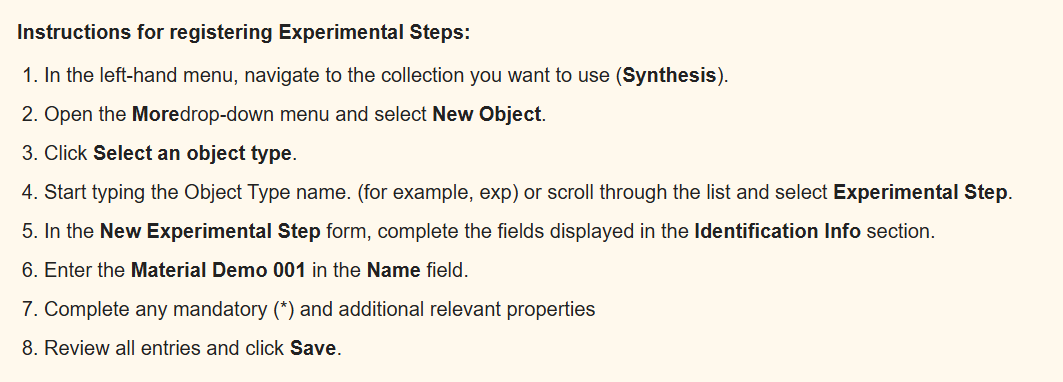

### Before proceeding, if you are unsure about which collection is at which index, you may use this function:

### search_collection(project,'all')

#### This will provide you the indices and names of all the collections in the project and then you may use a specific collection using the index like so:

### col = project.get_collections()[0]

The 0 above is for the index

In [23]:
search_collection(project,'all')

Indices		Collections
0		Synthesis
1		Treatment non-destructive
2		Structure_TEM
3		Parameter 1
4		Parameter 2


In [24]:
project.get_collections()[0].props.all()
#For me at the time of creating the notebook, synthesis is at [0] index but it may change for you
#Please use the index for synthesis from the output of the previous cell

{'$name': 'Synthesis',
 '$default_object_type': None,
 '$default_collection_view': None}

In [25]:
col = project.get_collections()[0]#saving synthesis in col variable for further use
col.props()#this should also result in synthesis and not some other collection

{'$name': 'Synthesis',
 '$default_object_type': None,
 '$default_collection_view': None}

In [26]:
sample = o.new_sample(#code is autogenerated for the sample unlike in collections where the user has to provide a code for the collection
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      = {"$name": "Material Demo 001", "experimental_step.experimental_description": "To synthesize a demo material"}
)
sample

attribute,value
code,
type,EXPERIMENTAL_STEP
project,/VP.1_NARSHAD/MATERIAL_SYNTHESISS
parents,[]
children,[]
container,
components,[]
space,VP.1_NARSHAD
experiment,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_1
tags,[]


In [27]:
sample.save()#to save it into the data store

sample successfully created.


### Step 4

We will now register an experiment using a premade template that allows reusability and fills out a lot of metadata fields for the experiment

In [28]:
col.props.all()#this is the collection called synthesis

{'$name': 'Synthesis',
 '$default_object_type': None,
 '$default_collection_view': None}

In [29]:
template_sample = o.new_sample(#code is autogenerated for the sample unlike in collections where the user has to provide a code for the experiment
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Material Synthesis']#templates is a dictionary defined in helper.py file
)#you can press ctrl + click 'templates' on the above line to go to the dictionary where templates are defined
template_sample

attribute,value
code,
type,EXPERIMENTAL_STEP
project,/VP.1_NARSHAD/MATERIAL_SYNTHESISS
parents,[]
children,[]
container,
components,[]
space,VP.1_NARSHAD
experiment,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_1
tags,[]


In [30]:
template_sample.save()#save this into the data store

sample successfully created.


Upon executing the next cell, you can check in the gui or here in the script that there are now two experiments under synthesis:

Material Demo 001 (created in step 3) and Material Synthesis (created in step 4)

In [31]:
col.get_objects()#using this you can confirm that there are now 2 experiments

,permId,identifier,registrationDate,modificationDate,type,registrator,modifier
0,20260731150739643-7914,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5018,2026-07-31 15:07:40,2026-07-31 15:07:40,EXPERIMENTAL_STEP,narshad,narshad
1,20260731150752941-7915,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5019,2026-07-31 15:07:53,2026-07-31 15:07:53,EXPERIMENTAL_STEP,narshad,narshad


### Step 5: Edit Collections and Objects (experiments)


We will be renaming the collection 'Structure TEM' to 'Parameter 2 Analysis' 

Since there are multiple collections in our project, we will use the search_collection() function for ease

In [32]:
search_collection(project,'all')

Indices		Collections
0		Synthesis
1		Treatment non-destructive
2		Structure_TEM
3		Parameter 1
4		Parameter 2


In [33]:
exp_to_rename = project.get_experiments()[2]#We will be renaming Structure_TEM so we save it in the exp_to_rename variable
#Note, Structure_TEM may not be at index 2 for you, please refer to the output of the previous cell to find the index for you

In [34]:
exp_to_rename.props.all()#we run this to see the field we want to edit, which is the $name as you can see below

{'$name': 'Structure_TEM',
 '$default_object_type': None,
 '$default_collection_view': None}

In [35]:
exp_to_rename.props['$name'] = 'Parameter 2 Analysis' #this is the new name we want to give to the experiment

In [36]:
exp_to_rename.props.all()#run this to check if the change is applied locally

{'$name': 'Parameter 2 Analysis',
 '$default_object_type': None,
 '$default_collection_view': None}

In [37]:
exp_to_rename.save()#this will save the changes made to the experiment

experiment successfully updated.


attribute,value
code,MATERIAL_SYNTHESISS_EXP_3
permId,20260731150647996-7911
identifier,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_3
type,COLLECTION
project,/VP.1_NARSHAD/MATERIAL_SYNTHESISS
tags,[]
registrator,narshad
registrationDate,2026-07-31 15:06:48
modifier,narshad
modificationDate,2026-07-31 15:08:32


### Deletion of objects

We will be deleting the object called 'Material Demo 001'

In [38]:
#Material Demo 001 is an experiment under the collection 'Synthesis', that is why we need to first store synthesis in the variable
search_collection(project,'synthesis')#this is another way to use the function

Indices		Collections
0		Synthesis


In [39]:
col = project.get_collections()[0]#for me the above cell's output is index [0] for synthesis, please check what it is for you
col.props.all()

{'$name': 'Synthesis',
 '$default_object_type': None,
 '$default_collection_view': None}

In [40]:
col.get_samples()#this prints the two experiments we have currently in synthesis
#Material Demo 001 and and the template experiment called Material Synthesis

,permId,identifier,registrationDate,modificationDate,type,registrator,modifier
0,20260731150739643-7914,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5018,2026-07-31 15:07:40,2026-07-31 15:07:40,EXPERIMENTAL_STEP,narshad,narshad
1,20260731150752941-7915,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5019,2026-07-31 15:07:53,2026-07-31 15:07:53,EXPERIMENTAL_STEP,narshad,narshad


In [41]:
#since it is confusing to see which experiment is which from the above cell's output, we must print their properties to make sure we dont select the wrong experiment
for x in col.get_samples():
    print(x.props.all())#index for the next cell is the position of Material Demo 001 from the output of this cell

{'$name': 'Material Demo 001', '$show_in_project_overview': None, 'finished_flag': None, 'start_date': None, 'end_date': None, 'experimental_step.experimental_goals': None, 'experimental_step.experimental_description': 'To synthesize a demo material', 'experimental_step.experimental_results': None, 'experimental_step.spreadsheet': None, 'reference': None, 'publication': None, 'notes': None, '$xmlcomments': None}
{'$name': 'Material Synthesis', '$show_in_project_overview': 'true', 'finished_flag': 'false', 'start_date': None, 'end_date': None, 'experimental_step.experimental_goals': 'To synthesize and process functional materials with controlled composition, structure, and properties using a reproducible and parameterized workflow suitable for a wide range of material classes (e.g., powders, thin films, composites, nanomaterials).', 'experimental_step.experimental_description': 'Very long description, can fix it later', 'experimental_step.experimental_results': None, 'experimental_step.

In [42]:
sample_to_be_deleted = col.get_samples()[0]#for me, Material Demo 001 was the first row, so index is [0]
sample_to_be_deleted.delete('Add reason here for deletion')

sample 20260731150739643-7914 successfully deleted.


In [43]:
col.get_samples()#now we see only one experiment

,permId,identifier,registrationDate,modificationDate,type,registrator,modifier
0,20260731150752941-7915,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5019,2026-07-31 15:07:53,2026-07-31 15:07:53,EXPERIMENTAL_STEP,narshad,narshad


In [44]:
col.get_samples()[0].props.all()#since we deleted Material Demo 001, the only experiment in this collection is Material Synthesis.

{'$name': 'Material Synthesis',
 '$show_in_project_overview': 'true',
 'finished_flag': 'false',
 'start_date': None,
 'end_date': None,
 'experimental_step.experimental_goals': 'To synthesize and process functional materials with controlled composition, structure, and properties using a reproducible and parameterized workflow suitable for a wide range of material classes (e.g., powders, thin films, composites, nanomaterials).',
 'experimental_step.experimental_description': 'Very long description, can fix it later',
 'experimental_step.experimental_results': None,
 'experimental_step.spreadsheet': None,
 'reference': 'Literature references for synthesis routes Internal protocols / SOPs',
 'publication': None,
 'notes': 'Free text for additional notes, optimization insights, or anomalies',
 '$xmlcomments': None}

### Step 6: Register additional Experimental Steps using Templates

We will be registering multiple Experimental Steps (samples/experiments) using the table below.

For this step, we will use the knowledge that was applied in step 4

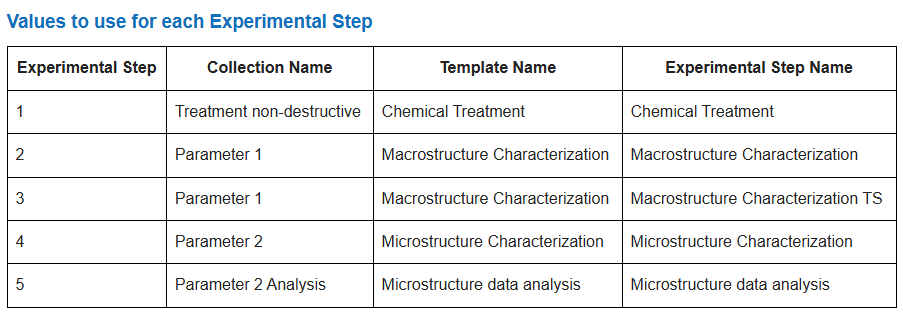

In [45]:
search_collection(project,'all')# we use this since we need to know the indices of the collections to add samples to them

Indices		Collections
0		Synthesis
1		Treatment non-destructive
2		Parameter 2 Analysis
3		Parameter 1
4		Parameter 2


In [46]:
col = project.get_experiments()[1]#According to the above cell, for me index 1 is for Treatment non-destructive
col.props.all()

{'$name': 'Treatment non-destructive',
 '$default_object_type': None,
 '$default_collection_view': None}

In [47]:
#We will add an experiment using the Chemical Treatment template under the collection 'Treatment non-destructive'
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Chemical Treatment']
)
template_sample.save()

sample successfully created.


In [48]:
search_collection(project,'parameter 1')#use this as many times as needed.

Indices		Collections
3		Parameter 1


In [49]:
#the next collection in the table of values to edit is parameter 1
col = project.get_experiments()[3]
col.props.all()

{'$name': 'Parameter 1',
 '$default_object_type': None,
 '$default_collection_view': None}

In [50]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Macrostructure Characterization']
)
template_sample.save()

sample successfully created.


In [51]:
#the next is also parameter 1 but this time with Macrostructure Characterization TS

template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Macrostructure Characterization TS']
)
template_sample.save()

sample successfully created.


In [52]:
search_collection(project,'parameter 2')

Indices		Collections
2		Parameter 2 Analysis
4		Parameter 2


In [53]:
#then the next collection is Parameter 2
col = project.get_experiments()[4]
col.props.all()

{'$name': 'Parameter 2',
 '$default_object_type': None,
 '$default_collection_view': None}

In [54]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Microstructure Characterization']
)
template_sample.save()

sample successfully created.


In [55]:
search_collection(project,'analysis')

Indices		Collections
2		Parameter 2 Analysis


In [56]:
#the last collection to do is Parameter 2 Analysis
col = project.get_experiments()[2]
col.props.all()

{'$name': 'Parameter 2 Analysis',
 '$default_object_type': None,
 '$default_collection_view': None}

In [57]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Microstructure data analysis']
)
template_sample.save()

sample successfully created.


### Step 7: Upload Data

We will be uploading a dataset (Parameter1_Macroscopic.zip) of type Raw Data into the Experimental Step called 'Macrostructure Characterization' which is under the collection 'Parameter 1'. We will also be adding some comments with the dataset

In [58]:
search_collection(project,'parameter 1')

Indices		Collections
3		Parameter 1


In [59]:
project.get_collections()[3].props.all()

{'$name': 'Parameter 1',
 '$default_object_type': None,
 '$default_collection_view': None}

In [ ]:
col = project.get_collections()[3]#saving it in a variable to use it

In [61]:
#then we need the sample of macrostructure characterization of which you need to see the position in the output of this cell for its index
for x in col.get_samples():
    print(x.props.all())

{'$name': 'Macrostructure Characterization', '$show_in_project_overview': None, 'finished_flag': None, 'start_date': None, 'end_date': None, 'experimental_step.experimental_goals': None, 'experimental_step.experimental_description': None, 'experimental_step.experimental_results': None, 'experimental_step.spreadsheet': None, 'reference': None, 'publication': None, 'notes': None, '$xmlcomments': None}
{'$name': 'Macrostructure Characterization TS', '$show_in_project_overview': None, 'finished_flag': None, 'start_date': None, 'end_date': None, 'experimental_step.experimental_goals': None, 'experimental_step.experimental_description': None, 'experimental_step.experimental_results': None, 'experimental_step.spreadsheet': None, 'reference': None, 'publication': None, 'notes': None, '$xmlcomments': None}


In [62]:
sample = col.get_samples()[0]#We store this sample in a variable

In [63]:
#Run this if you do not know the code for Raw Data
o.get_dataset_types()#we need raw data which is on index [2]

,permId,code,description,mainDataSetPattern,mainDataSetPath,disallowDeletion,modificationDate,validationPlugin
0,UNKNOWN,UNKNOWN,Unknown,None,None,False,2025-03-19 14:45:12,
1,ELN_PREVIEW,ELN_PREVIEW,NaN,None,None,False,2025-03-20 11:49:24,
2,RAW_DATA,RAW_DATA,NaN,None,None,False,2025-03-20 11:49:24,
3,PROCESSED_DATA,PROCESSED_DATA,NaN,None,None,False,2025-03-20 11:49:24,
4,ANALYZED_DATA,ANALYZED_DATA,NaN,None,None,False,2025-03-20 11:49:24,
5,ATTACHMENT,ATTACHMENT,NaN,None,None,False,2025-03-20 11:49:24,
6,OTHER_DATA,OTHER_DATA,NaN,None,None,False,2025-03-20 11:49:24,
7,SOURCE_CODE,SOURCE_CODE,NaN,None,None,False,2025-03-20 11:49:24,
8,ANALYSIS_NOTEBOOK,ANALYSIS_NOTEBOOK,NaN,None,None,False,2025-03-20 11:49:24,
9,PUBLICATION_DATA,PUBLICATION_DATA,NaN,None,None,False,2025-03-20 11:49:24,


In [64]:
ds_new = o.new_dataset(
    type       = 'RAW_DATA',#the code from the table above if run
    sample     = sample.identifier,
    zipfile    = 'Data/Parameter1_Macroscopic.zip',#this is the dataset we downloaded and extracted at the start of the notebook
    props      = {'$name': 'Parameter 1 raw' ,'notes' : 'Synthetic example images for demo purpose.' }#We give it a name and some comments
)
ds_new.save()

DataSet successfully created.


attribute,value
code,20260731151103795-7921
permId,20260731151103795-7921
type,RAW_DATA
kind,PHYSICAL
experiment,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_4
sample,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5021
parents,[]
children,[]
components,[]
containers,[]


### Exercise: Uploading data to the ELN preview

We will now add an image dataset (Synthetic-image1.png) of type ELN Preview to the experimental step 'Macrostructure Characterization' under the collection 'Parameter 1'

In [65]:
o.get_dataset_types()#Again, run this if you do not know the code for ELN Preview which is index [1]

,permId,code,description,mainDataSetPattern,mainDataSetPath,disallowDeletion,modificationDate,validationPlugin
0,UNKNOWN,UNKNOWN,Unknown,None,None,False,2025-03-19 14:45:12,
1,ELN_PREVIEW,ELN_PREVIEW,NaN,None,None,False,2025-03-20 11:49:24,
2,RAW_DATA,RAW_DATA,NaN,None,None,False,2025-03-20 11:49:24,
3,PROCESSED_DATA,PROCESSED_DATA,NaN,None,None,False,2025-03-20 11:49:24,
4,ANALYZED_DATA,ANALYZED_DATA,NaN,None,None,False,2025-03-20 11:49:24,
5,ATTACHMENT,ATTACHMENT,NaN,None,None,False,2025-03-20 11:49:24,
6,OTHER_DATA,OTHER_DATA,NaN,None,None,False,2025-03-20 11:49:24,
7,SOURCE_CODE,SOURCE_CODE,NaN,None,None,False,2025-03-20 11:49:24,
8,ANALYSIS_NOTEBOOK,ANALYSIS_NOTEBOOK,NaN,None,None,False,2025-03-20 11:49:24,
9,PUBLICATION_DATA,PUBLICATION_DATA,NaN,None,None,False,2025-03-20 11:49:24,


In [66]:
ds_new = o.new_dataset(
    type       = 'ELN_PREVIEW',
    sample     = sample.identifier,
    file       = 'Data/Synthetic-image1.png',#note that the variable name is now file instead of zipfile because its a normal file and not a zip file
    props      = {'$name': 'Synthetic image1' ,'notes' : 'This is an artificial example created for demonstration testing.' }
)
ds_new.save()

DataSet successfully created.


attribute,value
code,20260731151108432-7922
permId,20260731151108432-7922
type,ELN_PREVIEW
kind,PHYSICAL
experiment,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_4
sample,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5021
parents,[]
children,[]
components,[]
containers,[]


### Exercise: Uploading an attachment to describe an uploaded image

We will be adding a dataset(README-Synthetic-image1.txt) of type attachment into the the experimental step 'Macrostructure Characterization' under the collection 'Parameter 1'

In [67]:
o.get_dataset_types()#Again, run this if you do not know the code for attachment which is on index [5]

,permId,code,description,mainDataSetPattern,mainDataSetPath,disallowDeletion,modificationDate,validationPlugin
0,UNKNOWN,UNKNOWN,Unknown,None,None,False,2025-03-19 14:45:12,
1,ELN_PREVIEW,ELN_PREVIEW,NaN,None,None,False,2025-03-20 11:49:24,
2,RAW_DATA,RAW_DATA,NaN,None,None,False,2025-03-20 11:49:24,
3,PROCESSED_DATA,PROCESSED_DATA,NaN,None,None,False,2025-03-20 11:49:24,
4,ANALYZED_DATA,ANALYZED_DATA,NaN,None,None,False,2025-03-20 11:49:24,
5,ATTACHMENT,ATTACHMENT,NaN,None,None,False,2025-03-20 11:49:24,
6,OTHER_DATA,OTHER_DATA,NaN,None,None,False,2025-03-20 11:49:24,
7,SOURCE_CODE,SOURCE_CODE,NaN,None,None,False,2025-03-20 11:49:24,
8,ANALYSIS_NOTEBOOK,ANALYSIS_NOTEBOOK,NaN,None,None,False,2025-03-20 11:49:24,
9,PUBLICATION_DATA,PUBLICATION_DATA,NaN,None,None,False,2025-03-20 11:49:24,


In [68]:
ds_new = o.new_dataset(
    type       = 'ATTACHMENT',
    sample     = sample.identifier,
    file       = 'Data/README-Synthetic-image1.txt',#note that the variable name is now file instead of zipfile because its a normal file and not a zip file
    props      = {'$name': 'README Synthetic image1' ,'notes' : 'This is a README file to explain synthetic image1.' }
)
ds_new.save()

DataSet successfully created.


attribute,value
code,20260731151112619-7923
permId,20260731151112619-7923
type,ATTACHMENT
kind,PHYSICAL
experiment,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/MATERIAL_SYNTHESISS_EXP_4
sample,/VP.1_NARSHAD/MATERIAL_SYNTHESISS/EXP5021
parents,[]
children,[]
components,[]
containers,[]
